In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# Load dataset cancer
df = pd.read_csv('../data/cancer.csv')
print('Shape:', df.shape)
df.head()


Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Info dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# Statistik deskriptif
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [5]:
# Cek missing values dan duplikasi
print('Missing values:')
print(df.isnull().sum().sum())
print('\nDuplikasi:')
print(df.duplicated().sum())


Missing values:
569

Duplikasi:
0


In [6]:
# Info tentang diagnosis (target)
print('Target classes:')
print(df['diagnosis'].unique())
print('\nDistribusi diagnosis:')
print(df['diagnosis'].value_counts())


Target classes:
['M' 'B']

Distribusi diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [7]:
# Data preparation: Drop id & diagnosis columns, encode target
df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Encode diagnosis (M=1, B=0)
y = (df_clean['diagnosis'] == 'M').astype(int)
X = df_clean.drop(columns=['diagnosis'])

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('X columns (fitur):', X.columns.tolist()[:5], '...')


Shape X: (569, 30)
Shape y: (569,)
X columns (fitur): ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean'] ...


In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Shape X_train:', X_train.shape)
print('Shape X_test:', X_test.shape)
print('Shape y_train:', y_train.shape)
print('Shape y_test:', y_test.shape)


Shape X_train: (455, 30)
Shape X_test: (114, 30)
Shape y_train: (455,)
Shape y_test: (114,)


In [9]:
# Normalisasi dengan StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train_scaled (first 5 rows):')
print(X_train_scaled[:5])


X_train_scaled (first 5 rows):
[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 -6.31833818e-01 -6.04281166e-01 -3.03074908e-01
   5.21543093e-01 -4.54522896e-01 -6.04377961e-01 -1.00104604e+00
  -5.85429002e-01 -4.93453793e-01  4.03212009e-01 -7.68173276e-01
  -4.79187222e-01  1.14508478e-01 -1.42950761e-01 -5.77397732e-01
  -5.82458953e-01 -1.69029101e+00 -6.11934288e-01 -5.87013537e-01
   2.73581959e-01 -8.14844486e-01 -7.12666415e-01 -3.23207881e-01
  -1.37576

In [10]:
# SVM tanpa PCA (baseline)
svm_no_pca = SVC(kernel='rbf', random_state=42, gamma='scale')
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print(f'Akurasi SVM tanpa PCA: {acc_no_pca:.4f}')

print('\nClassification Report (tanpa PCA):')
print(classification_report(y_test, y_pred_no_pca, target_names=['Benign', 'Malignant']))


Akurasi SVM tanpa PCA: 0.9737

Classification Report (tanpa PCA):
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [11]:
# PCA dengan 3 komponen
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Shape X_train_pca:', X_train_pca.shape)
print('Shape X_test_pca:', X_test_pca.shape)


Shape X_train_pca: (455, 3)
Shape X_test_pca: (114, 3)


In [12]:
# Explained variance ratio
explained_var = pca.explained_variance_ratio_
print('Explained Variance Ratio per komponen:', explained_var)
print('Total Explained Variance Ratio (3 komponen):', np.sum(explained_var))


Explained Variance Ratio per komponen: [0.44593522 0.18545255 0.09584641]
Total Explained Variance Ratio (3 komponen): 0.7272341886241546


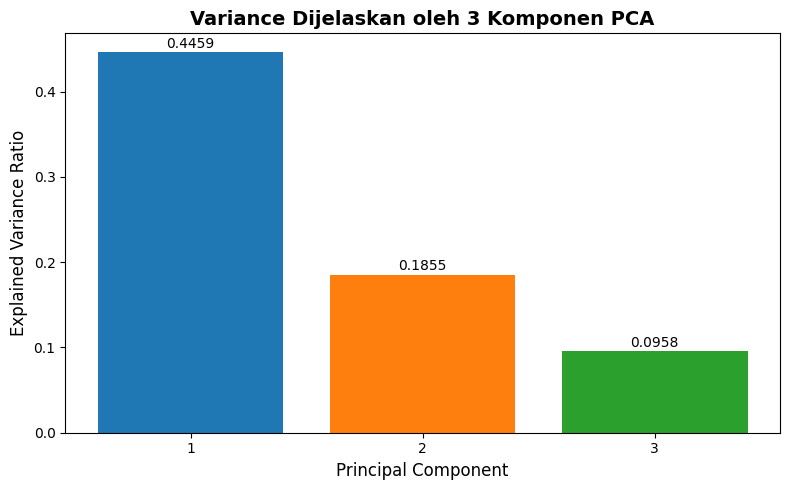

In [13]:
# Visualisasi explained variance per komponen
plt.figure(figsize=(8, 5))
plt.bar([1, 2, 3], explained_var, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Variance Dijelaskan oleh 3 Komponen PCA', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3])

for i, v in enumerate(explained_var):
    plt.text(i+1, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [14]:
# SVM dengan PCA (3 komponen)
svm_pca = SVC(kernel='rbf', random_state=42, gamma='scale')
svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print(f'Akurasi SVM dengan PCA (3 komponen): {acc_pca:.4f}')

print('\nClassification Report (dengan PCA):')
print(classification_report(y_test, y_pred_pca, target_names=['Benign', 'Malignant']))


Akurasi SVM dengan PCA (3 komponen): 0.9561

Classification Report (dengan PCA):
              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97        72
   Malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



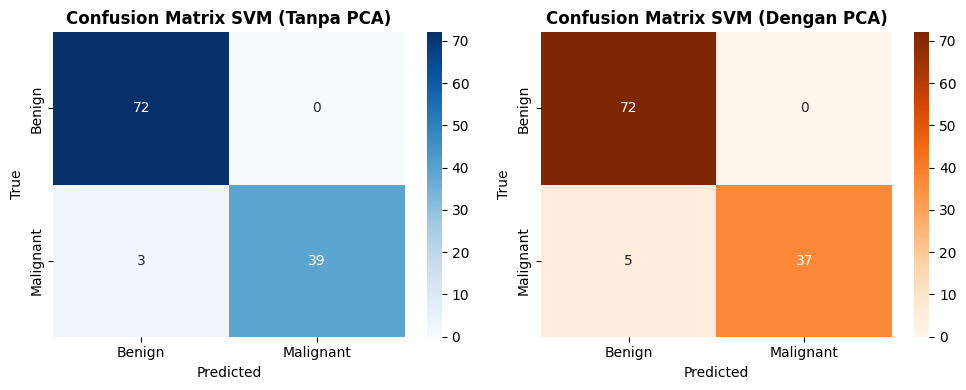

In [15]:
# Confusion matrix tanpa PCA
cm_no_pca = confusion_matrix(y_test, y_pred_no_pca)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm_no_pca, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix SVM (Tanpa PCA)', fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')

# Confusion matrix dengan PCA
cm_pca = confusion_matrix(y_test, y_pred_pca)

plt.subplot(1, 2, 2)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix SVM (Dengan PCA)', fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()


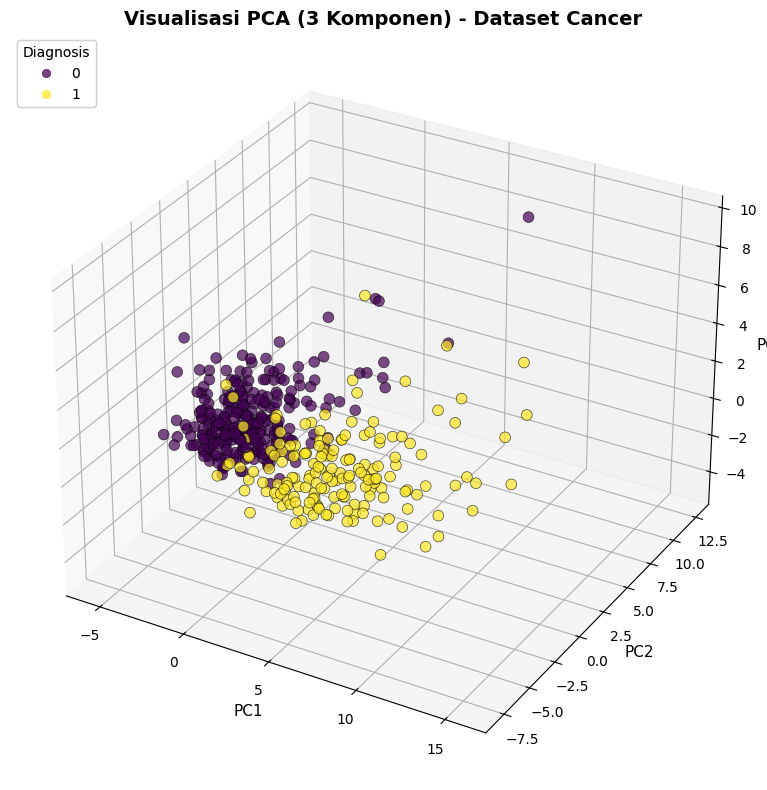

In [16]:
# Visualisasi 3D PCA - Training data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train,
    s=60,
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

ax.set_title('Visualisasi PCA (3 Komponen) - Dataset Cancer', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_zlabel('PC3', fontsize=11)

legend1 = ax.legend(*scatter.legend_elements(), title='Diagnosis', loc='upper left')
ax.add_artist(legend1)

plt.tight_layout()
plt.show()


In [17]:
# Tabel perbandingan hasil
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA (3 Komponen)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Total Variance Dijelaskan': [None, f'{np.sum(explained_var):.4f}']
})

print('Tabel Perbandingan:')
display(comparison)


Tabel Perbandingan:


,Model,Jumlah Fitur,Akurasi,Total Variance Dijelaskan
0,SVM Tanpa PCA,30,0.973684,None
1,SVM Dengan PCA (3 Komponen),3,0.956140,0.7272


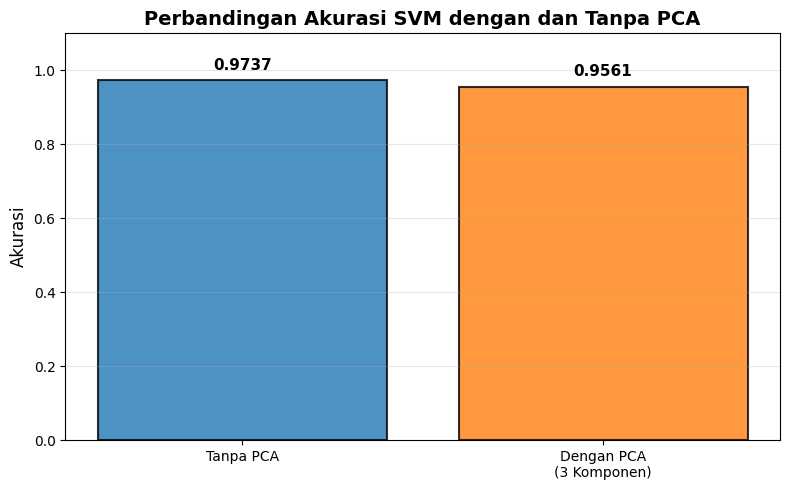

In [18]:
# Visualisasi perbandingan akurasi
plt.figure(figsize=(8, 5))
models = ['Tanpa PCA', 'Dengan PCA\n(3 Komponen)']
accuracies = [acc_no_pca, acc_pca]
colors = ['#1f77b4', '#ff7f0e']

bars = plt.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
plt.title('Perbandingan Akurasi SVM dengan dan Tanpa PCA', fontsize=14, fontweight='bold')
plt.ylabel('Akurasi', fontsize=12)
plt.ylim([0, 1.1])

for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f'{acc:.4f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


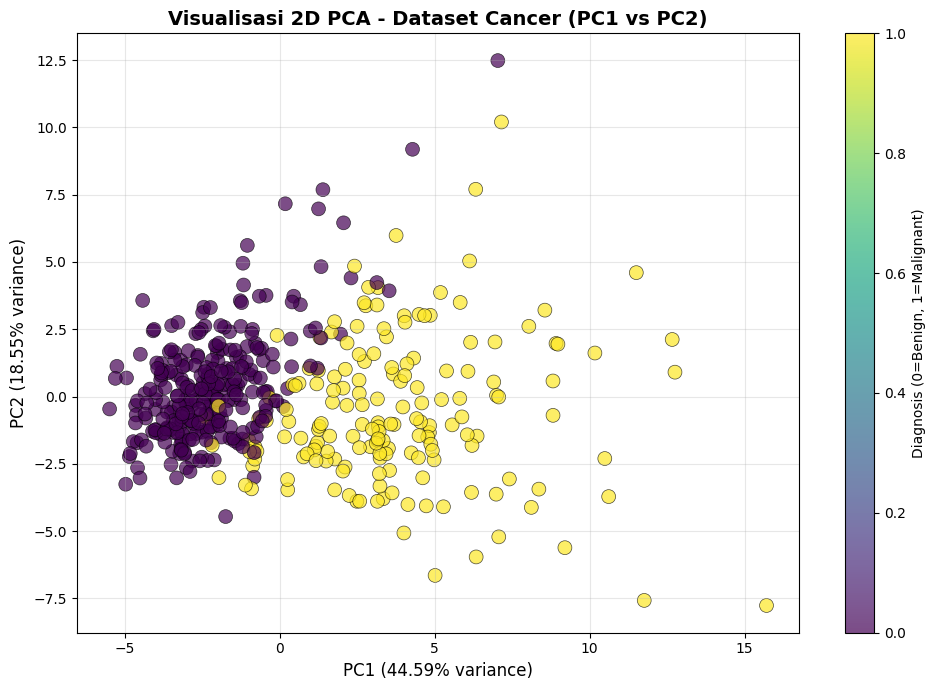

In [19]:
# Visualisasi 2D PCA (PC1 vs PC2)
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    s=100,
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

plt.xlabel(f'PC1 ({explained_var[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_var[1]:.2%} variance)', fontsize=12)
plt.title('Visualisasi 2D PCA - Dataset Cancer (PC1 vs PC2)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, label='Diagnosis (0=Benign, 1=Malignant)')

plt.tight_layout()
plt.show()


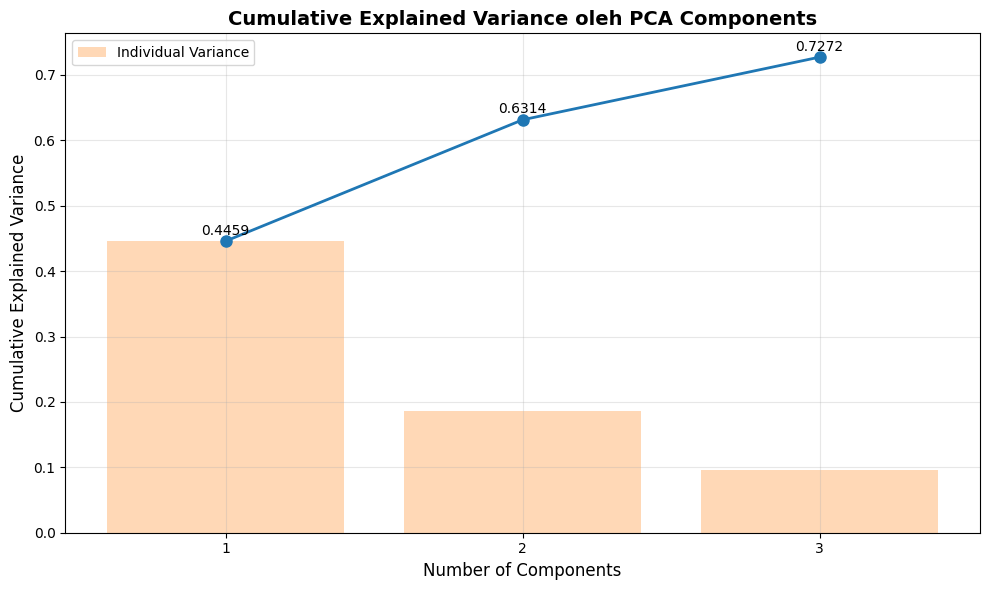

In [20]:
# Visualisasi cumulative explained variance
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.plot([1, 2, 3], cumulative_var, marker='o', linestyle='-', linewidth=2, markersize=8, color='#1f77b4')
plt.bar([1, 2, 3], explained_var, alpha=0.3, color='#ff7f0e', label='Individual Variance')

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Cumulative Explained Variance oleh PCA Components', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3])
plt.grid(True, alpha=0.3)
plt.legend()

for i, (comp, cum_var) in enumerate(zip([1, 2, 3], cumulative_var)):
    plt.text(comp, cum_var + 0.01, f'{cum_var:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [21]:
# Principal Components (loading)
pca_components = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)

print('PCA Components (Feature Loadings):')
display(pca_components)


PCA Components (Feature Loadings):


,PC1,PC2,PC3
radius_mean,0.217057,-0.239776,-0.008311
texture_mean,0.101900,-0.061533,0.042622
perimeter_mean,0.225804,-0.220949,-0.008682
area_mean,0.219079,-0.236925,0.026774
smoothness_mean,0.148588,0.177063,-0.123747
compactness_mean,0.241928,0.139921,-0.072390
concavity_mean,0.257761,0.060089,0.006244
concave points_mean,0.260383,-0.040533,-0.033120
symmetry_mean,0.142086,0.193612,-0.031526
fractal_dimension_mean,0.071593,0.366648,-0.024754


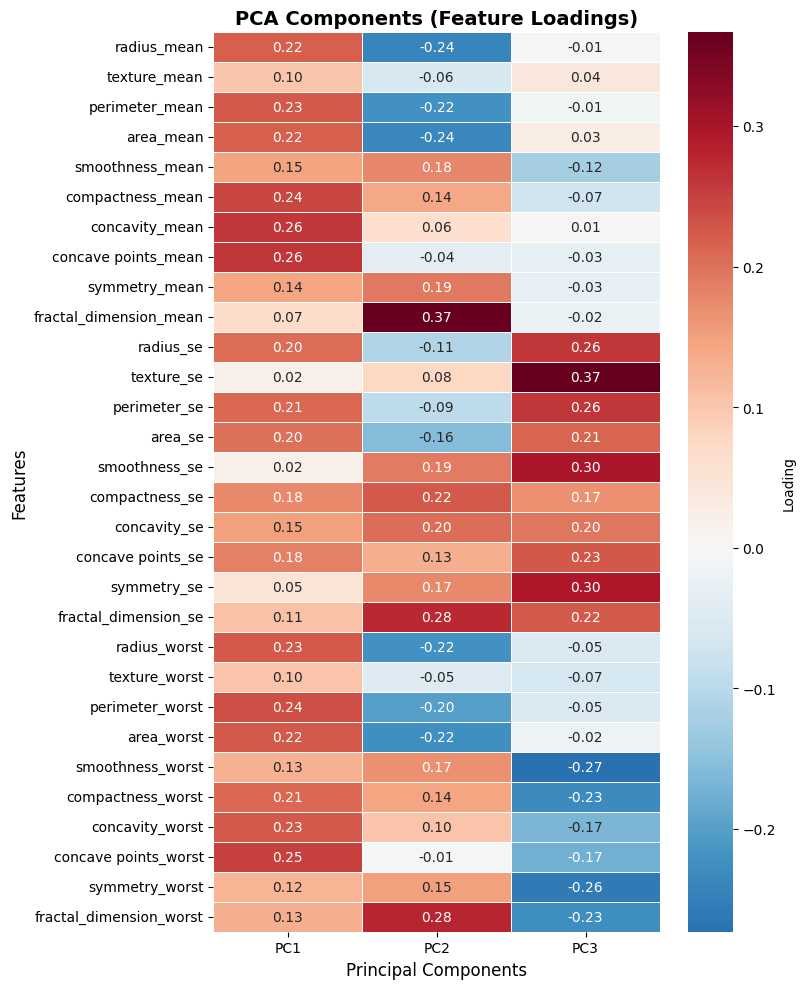

In [22]:
# Heatmap PCA components
plt.figure(figsize=(8, 10))
sns.heatmap(pca_components, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading'}, linewidths=0.5)
plt.title('PCA Components (Feature Loadings)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()


In [23]:
# Kesimpulan
print('='*70)
print('KESIMPULAN PCA - CANCER DATASET')
print('='*70)
print(f'\n1. Dataset Cancer:')
print(f'   - Total features (asli): {X_train_scaled.shape[1]}')
print(f'   - Total samples: {len(X)}')
print(f'   - Kelas: 2 (Benign vs Malignant)')

print(f'\n2. PCA Results:')
print(f'   - Jumlah komponen yang digunakan: 3')
print(f'   - Variance dijelaskan PC1: {explained_var[0]:.2%}')
print(f'   - Variance dijelaskan PC2: {explained_var[1]:.2%}')
print(f'   - Variance dijelaskan PC3: {explained_var[2]:.2%}')
print(f'   - Total variance: {np.sum(explained_var):.2%}')

print(f'\n3. Model Performance:')
print(f'   - Akurasi SVM tanpa PCA (30 fitur): {acc_no_pca:.4f}')
print(f'   - Akurasi SVM dengan PCA (3 fitur): {acc_pca:.4f}')
print(f'   - Selisih akurasi: {abs(acc_pca - acc_no_pca):.4f}')

print(f'\n4. Kesimpulan:')
if acc_pca >= acc_no_pca:
    print(f'   ✓ PCA mempertahankan/meningkatkan akurasi dengan reduksi dimensi 90%')
else:
    print(f'   ✓ PCA sedikit menurunkan akurasi tapi mengurangi dimensi 90%')
print(f'   ✓ 3 komponen PCA cukup untuk menangkap {np.sum(explained_var):.2%} informasi')
print(f'   ✓ Komputasi lebih cepat dengan fitur yang lebih sedikit')

print('='*70)


KESIMPULAN PCA - CANCER DATASET

1. Dataset Cancer:
   - Total features (asli): 30
   - Total samples: 569
   - Kelas: 2 (Benign vs Malignant)

2. PCA Results:
   - Jumlah komponen yang digunakan: 3
   - Variance dijelaskan PC1: 44.59%
   - Variance dijelaskan PC2: 18.55%
   - Variance dijelaskan PC3: 9.58%
   - Total variance: 72.72%

3. Model Performance:
   - Akurasi SVM tanpa PCA (30 fitur): 0.9737
   - Akurasi SVM dengan PCA (3 fitur): 0.9561
   - Selisih akurasi: 0.0175

4. Kesimpulan:
   ✓ PCA sedikit menurunkan akurasi tapi mengurangi dimensi 90%
   ✓ 3 komponen PCA cukup untuk menangkap 72.72% informasi
   ✓ Komputasi lebih cepat dengan fitur yang lebih sedikit
